In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Zadanie 1. 
Napisz program, który pozwoli użytkownikowi na wprowadzenie dowolnej ilości wartości temperatury. Kiedy użytkownik wpisze słowo *stop* program przestaje zbierać dane. Wprowadzone wartości mają zostać przepisane na tablicę NumPy wykorzystując typ, który pozwoli najbardziej oszczędzić pamięć operacyjną. Oblicz średnią temperaturę i wyznacz temperatury maksymalną i minimalną. Narysuj wykres boxplot ze wszystkich temperatur i porównaj czy Twoje wyniki zgadzają się z tymi na wykresie. Opisz wnioski.

In [16]:
temp =  []
while True:
    temp_val = input("podaj proszę temperature lub wpisz \"stop\" aby zakończyć: ")
    if temp_val == "stop":
        break
    temp_val_rplc = temp_val.replace(',', '.')
    try:
        value = float(temp_val_rplc)
        temp.append(value)
    except ValueError:
        print("NIEPRAWIDŁOWA WARTOŚĆ !!!")

print("wprowadzone temperatury:", temp)

wprowadzone temperatury: [20.0, 30.0, 40.0, 10.0, 15.0, 25.0, 100.0]


In [17]:
temp_arr = np.array(temp, dtype=np.float16) 
temp_arr.dtype


dtype('float16')

In [18]:
mean = np.mean(temp_arr)
print("średnia temp:", mean)

średnia temp: 34.28


In [19]:
max = np.max(temp_arr)
print("najwyższa temp:", max)

najwyższa temp: 100.0


In [20]:
min = np.min(temp_arr)
print("najniższa temp:", min)

najniższa temp: 10.0


In [23]:
median = np.median(temp_arr)
print("mediana temp:", median)

mediana temp: 25.0


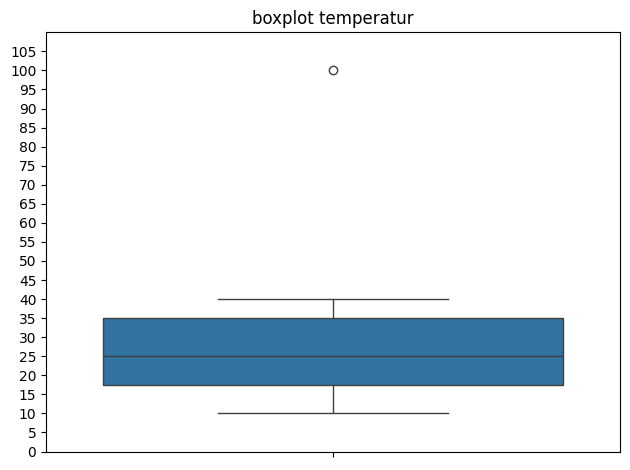

In [34]:
sns.boxplot(data=temp_arr)
plt.title("boxplot temperatur")
plt.ylim(0, 110)
plt.yticks(range(0, 110, 5))
plt.tight_layout()
plt.show()


**wnioski:** wizualizacja na boxplot zgadza się z moimi danymi, wprowadzone temperatury wachają się między 10 a 40 stopni z jedną odstającą wartością 100 stopni.<br>
- wąsy wykresu obejmują zakres od 10 do 40 stopni, co dobrze obrazuje zakres zmienności temperatur.
- linia środkowa (mediana) jest poprawnie zaznaczona około 25 stopni
- punkt outlier jest dobrze zaznaczony przy 100 stopniach, ponieważ ta wartość znaczeni różni się od reszty w podanym zakresie temperatur

# Zadanie 2.
Zasymuluj schemat mutacji genetycznych w DNA. W tym celu wygeneruj losową sekwencję DNA o długości $5000$ nukleotydów i przypisz do zmiennej `sekw`. Następnie wyznacz 20 wartości z przedziału od $1$ do $5$ w równych odległościach i zapisz w zmiennej `lambdy`. Dla każdej wartości wylosuj 10 liczb z rozkładu Poissona, gdzie wartości z tablicy `lambdy` to $\lambda$ w rozkładzie Poissona, i zapisz tylko medianę z wylosowanego wektora. Wprowadź tyle losowych zmian w wyjściowej sekwencji ile wskazuje losowanie Poissona dla danej wartości $\lambda$. Oblicz odległość między zmutowanymi sekwencjami do oryginalnej. Na wykresie liniowym przedstaw zależność odległości od użytej wartości $\lambda$. Wykorzystaj odległość Hamminga:
$$d_H(x,y)=\sum_{i=1}^n{[x_i\neq y_i]}$$

co oznacza, że każda pozycja, na której obie sekwencje mają różne nukleotydy zwiększa odległość o $1$.

In [35]:
n  = [ "A", "C", "G", "T" ]
lenght = 5000
sekw = np.random.choice(n, size=lenght)
print(sekw)

['G' 'C' 'A' ... 'A' 'A' 'T']


In [ ]:
lambdy= np.linspace(1, 5, num = 20)
print(lambdy)

[1.         1.21052632 1.42105263 1.63157895 1.84210526 2.05263158
 2.26315789 2.47368421 2.68421053 2.89473684 3.10526316 3.31578947
 3.52631579 3.73684211 3.94736842 4.15789474 4.36842105 4.57894737
 4.78947368 5.        ]


In [38]:
rand = []
for l in lambdy:
   rand_vec = np.random.poisson(lam=l, size=10)
   median = np.median(rand_vec)
   rand.append(median)
print(rand)

[np.float64(1.0), np.float64(1.0), np.float64(1.5), np.float64(1.5), np.float64(2.0), np.float64(1.5), np.float64(1.0), np.float64(3.0), np.float64(2.5), np.float64(3.0), np.float64(4.0), np.float64(3.0), np.float64(3.5), np.float64(3.0), np.float64(3.0), np.float64(5.0), np.float64(2.5), np.float64(4.5), np.float64(6.0), np.float64(7.0)]


In [39]:
dist = []
for mediana in rand:
    size = int(median)
    mut_seq = sekw.copy()
    indexes = np.random.choice(5000, size=size, replace=False)
    mix = np.random.choice(n, size=size)
    mut_seq[indexes] = mix
    ham_dist = np.sum(sekw != mut_seq)
    dist.append(ham_dist)
print(dist)


[np.int64(5), np.int64(5), np.int64(5), np.int64(3), np.int64(7), np.int64(6), np.int64(4), np.int64(7), np.int64(5), np.int64(7), np.int64(7), np.int64(4), np.int64(6), np.int64(6), np.int64(4), np.int64(4), np.int64(7), np.int64(4), np.int64(5), np.int64(5)]


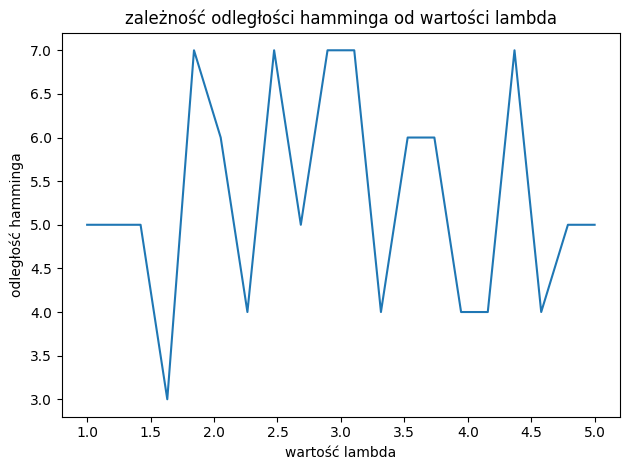

In [42]:
sns.lineplot(x=lambdy, y=dist)
plt.title("zależność odległości hamminga od wartości lambda")
plt.xlabel("wartość lambda")
plt.ylabel("odległość hamminga")
plt.tight_layout()
plt.show()

# Zadanie 3.

Rozwiąż poniższy układ równań wykorzystując algorytm macierzowy eliminacji Gaussa. Algorytm ten opiera się na trzech krokach:
1. Zapisz układ równań w postaci macierzowej - wybieramy współczynniki równań i wstawiamy je do macierzy, np. $2x+5y+3z=7$ ma współczynniki $[2,5,3,7]$ i wektor ten stanowi wektor macierzy.
2. Wykonuj operacje elementarne na wierszach aż do uzyskania macierzy schodkowej - operacje elementarne macierzy to:
    * zamiana dwóch wierszy miejscami;
    * mnożenie wiersza przez niezerową liczbę;
    * dodanie wielokrotności jednego wiersza do innego.

Postać schodkowa macierzy to forma, w której niezerowe wiersze tworzą schody: każdy kolejny wiersz zaczyna się dalej w prawo niż poprzedni, a wszystkie wiersze złożone wyłącznie z zer znajdują się na dole.
3. Wykonuj podstawianie wsteczne - ostatni niezerowy wiersz macierzy ma tylko dwie niezerowe wartości. Pierwsza to współczynnik ostatniej zmiennej, a druga to wartość, której będzie równa zmienna po przemnożeniu przez współczynnik. Przykładowo, ostatni wektor macierzy to 
$$\left[0,0,0,3,15\right]$$
w takim układzie podstawiamy: 
$$0x+0y+0z+3t=15$$
$$3t=15\quad|:3$$
$$t=5$$

W ten sposób podstawiając znane wartości można odnaleźć wartości pozostałych równań.

Układ równań do rozwiązania:
$$t+13u-5v-0.5w=10$$
$$-t+2u-v+x=4$$
$$10u+2v+5w-x=12$$
$$-3t+u-2v+5w=7$$
$$8t+6u-x=3$$

In [46]:
arr = np.array([
    [ 1,  13, -5, -0.5,  0],
    [-1,   2, -1,    0,  1],
    [ 0,  10,  2,    5, -1],
    [-3,   1, -2,    5,  0],
    [ 8,   6,  0,    0, -1]
], dtype=float)

In [47]:
arr2 = np.array([10, 4, 12, 7, 3], dtype=float)

In [48]:
res = np.linalg.solve(arr, arr2)

In [49]:
print("rozwiązanie [t, u, v, w, x]:", np.round(res, 3))

rozwiązanie [t, u, v, w, x]: [ 0.075  0.808 -0.012  1.278  2.447]


# Zadanie 4.
Tablica `ref` zawiera sekwencję referencyjną (punkt odniesienia), a tablica `sekw` zawiera sekwencje do sprawdzenia. Wykorzystując algorytm map-reduce, oceń jakość sekwencji w stosunku do referencji.

**Mapowanie:** oblicz odległość Hamminga wszystkich sekwencji w stosunku do referencji.

**Redukcja:** oblicz średnią odległość ze wszystkich sekwencji.

In [44]:
ref = np.array(["A","C","T","G"], dtype="S1")[np.random.randint(0, 4, 1000)]
sekw = np.array(["A","C","T","G"], dtype="S1")[np.random.randint(0, 4, (100, 1000))]

In [45]:
diff = (ref != sekw)
dist_ham = np.sum(diff, axis=1)
mean_dist = np.mean(dist_ham)
print("średnia odległość hamminga wynosi:", mean_dist)


średnia odległość hamminga wynosi: 750.25
